## Import Librairies

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#Basic Libraries
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np
import scipy.io as sio
import pandas as pd

import pickle
import pingouin as pg
from math import floor
from scipy import stats
import math
import random

#Homemade functions
# from plotsPaper import *
# from statsPaper import *

In [3]:
#Let's read our files
def read_pickle(pickle_file):
    with open(pickle_file, 'rb') as f:
        df = pickle.load(f)
    return df

# 5 sessions of data
df_trials1 = read_pickle('data/Copy of PDilemma_IzzySALandPeytonSAL_07_08_2014_dACC.pkl')
df_trials2 = read_pickle('data/Copy of PDilemma_IzzySALandPeytonSAL_07_09_2014_dACC.pkl')
df_trials3 = read_pickle('data/Copy of PDilemma_IzzySALandPeytonSAL_07_10_2014_dACC.pkl')
df_trials4 = read_pickle('data/Copy of PDilemma_IzzySALwTiggerSAL_07_11_2014_dACC.pkl')
df_trials5 = read_pickle('data/Copy of PDilemma_PeytonSALwIzzySAL_07_12_2014_dACC.pkl')

/var/folders/wd/fm72z_p13js16_j4p4vwjxg40000gn/T/ipykernel_26100/3626346752.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(f)


## Extract relevant variables for each trial

In [4]:
dataset = df_trials1 #example session
n_trials = len(dataset) #total number of completed trials

#Which monkey (1 or 2) went first for each trial
firstM = dataset['firstMonkey']

# decision for each player for each trial (0 defect, 1 cooperate)
decision_m1, decision_m2 = dataset['decision1'],dataset['decision2']

rx_m1,rx_m2 = dataset['Rx1'],dataset['Rx2'] #reaction time each player

In [5]:
print(decision_m1.head())
print("coop rate:", decision_m1.mean())

t  r  i  a  l  0  NaN  NaN    1.0
               1  NaN  NaN    0.0
               2  NaN  NaN    0.0
               3  NaN  NaN    0.0
               4  NaN  NaN    0.0
Name: decision1, dtype: float64
coop rate: 0.377431906614786


In [6]:
# Actually LOOK at the data — show the first session as a table
print("Number of trials:", len(df_trials1))
print("Columns:", list(df_trials1.columns))
print()

# Show the key behavioral columns as a spreadsheet-style table
df_trials1[['firstMonkey', 'decision1', 'decision2', 'past1', 'past2', 'Rx1', 'Rx2']].head(15)

Number of trials: 514
Columns: ['firstMonkey', 'decision1', 'decision2', 'past1', 'past2', 'ppast1', 'ppast2', 'future1', 'future2', 'startTime', 't_m1_decision', 't_m2_decision', 't_m1_goCue', 't_m2_goCue', 't_feedback', 't_reward_start', 't_totalTrial', 'Rx1', 'Rx2', 'M1_side', 'M2_side', 'condition', 'oxt', 'previous', 'spkTimes_m1', 'spkTimes_m2', 'pppast1', 'pppast2', 'ppppast1', 'ppppast2', 'pppppast1', 'pppppast2']



firstMonkey  decision1  decision2  past1  past2  \
t r i a l 0 NaN NaN          1.0        1.0        0.0    1.0    0.0   
          1 NaN NaN          2.0        0.0        0.0    1.0    0.0   
          2 NaN NaN          1.0        0.0        1.0    0.0    0.0   
          3 NaN NaN          2.0        0.0        1.0    0.0    1.0   
          4 NaN NaN          1.0        0.0        1.0    0.0    1.0   
          5 NaN NaN          1.0        0.0        1.0    0.0    1.0   
          6 NaN NaN          2.0        1.0        1.0    0.0    1.0   
          7 NaN NaN          1.0        0.0        1.0    1.0    1.0   
          8 NaN NaN          1.0        1.0        0.0    0.0    1.0   
          9 NaN NaN          2.0        0.0        1.0    1.0    0.0   
          1 0   NaN          2.0        1.0        1.0    0.0    1.0   
            1   NaN          1.0        1.0        1.0    1.0    1.0   
            2   NaN          2.0        1.0        1.0    1.0    1.0   
            3   NaN          1.0        1.0        1.0    1.0    1.0   
            4   NaN          2.0        1.0        1.0    1.0    1.0   

                          Rx1       Rx2  
t r i a l 0 NaN NaN  0.194225  0.154425  
          1 NaN NaN  0.300300  0.077300  
          2 NaN NaN  0.289700  0.157275  
          3 NaN NaN  0.117650  0.222275  
          4 NaN NaN  0.164025  0.113150  
          5 NaN NaN  0.144425  0.004875  
          6 NaN NaN  0.174600  0.118925  
          7 NaN NaN  0.369825  0.034900  
          8 NaN NaN  0.282275  2.316200  
          9 NaN NaN  0.191375  0.004800  
          1 0   NaN  0.248950  0.154525  
            1   NaN  2.094275  0.004850  
            2   NaN  0.193475  0.420475  
            3   NaN  0.615975  0.004850  
            4   NaN  0.210875  0.004825

In [7]:
# Is past1 just decision1 from the previous row? Let's verify.
check = df_trials1[['decision1', 'past1', 'decision2', 'past2']].head(6).copy()
check['decision1_shifted'] = df_trials1['decision1'].shift(1).head(6)
print(check)

                     decision1  past1  decision2  past2  decision1_shifted
t r i a l 0 NaN NaN        1.0    1.0        0.0    0.0                NaN
          1 NaN NaN        0.0    1.0        0.0    0.0                1.0
          2 NaN NaN        0.0    0.0        1.0    0.0                0.0
          3 NaN NaN        0.0    0.0        1.0    1.0                0.0
          4 NaN NaN        0.0    0.0        1.0    1.0                0.0
          5 NaN NaN        0.0    0.0        1.0    1.0                0.0


## Model evaluation

In [8]:
from scripts.harness import build_features, evaluate
from sklearn.linear_model import LogisticRegression
sessions = [df_trials1, df_trials2, df_trials3, df_trials4, df_trials5]

In [9]:
# --- both monkeys, all K, printed ---
for target in ['decision1', 'decision2']:
    monkey = 'Monkey 1' if target == 'decision1' else 'Monkey 2'
    for K in range(1, 9):
        result = evaluate(lambda: LogisticRegression(max_iter=1000), K=K, sessions=sessions, target=target)
        print(f"=== {monkey} ({target}), K={K} ===")
        print(f"accuracy:  {result['acc_mean']:.3f} ± {result['acc_std']:.3f}")
        print(f"balanced:  {result['bal_mean']:.3f} ± {result['bal_std']:.3f}")
        print(f"log-loss:  {result['loss_mean']:.3f} ± {result['loss_std']:.3f}")
        print(f"baseline:  {result['base_mean']:.3f}")
        print(f"per-fold accuracy: {[round(a,3) for a in result['per_fold_acc']]}")
        print()

=== Monkey 1 (decision1), K=1 ===
accuracy:  0.687 ± 0.035
balanced:  0.500 ± 0.000
log-loss:  0.606 ± 0.022
baseline:  0.687
per-fold accuracy: [0.624, 0.705, 0.707, 0.677, 0.724]

=== Monkey 1 (decision1), K=2 ===
accuracy:  0.689 ± 0.038
balanced:  0.533 ± 0.013
log-loss:  0.604 ± 0.023
baseline:  0.688
per-fold accuracy: [0.615, 0.706, 0.711, 0.698, 0.715]

=== Monkey 1 (decision1), K=3 ===
accuracy:  0.691 ± 0.032
balanced:  0.527 ± 0.012
log-loss:  0.603 ± 0.023
baseline:  0.687
per-fold accuracy: [0.63, 0.703, 0.716, 0.689, 0.719]

=== Monkey 1 (decision1), K=4 ===
accuracy:  0.690 ± 0.032
balanced:  0.527 ± 0.011
log-loss:  0.603 ± 0.023
baseline:  0.687
per-fold accuracy: [0.629, 0.7, 0.709, 0.691, 0.72]

=== Monkey 1 (decision1), K=5 ===
accuracy:  0.696 ± 0.032
balanced:  0.537 ± 0.017
log-loss:  0.601 ± 0.025
baseline:  0.688
per-fold accuracy: [0.642, 0.707, 0.717, 0.679, 0.736]

=== Monkey 1 (decision1), K=6 ===
accuracy:  0.697 ± 0.034
balanced:  0.537 ± 0.016
log-loss: 

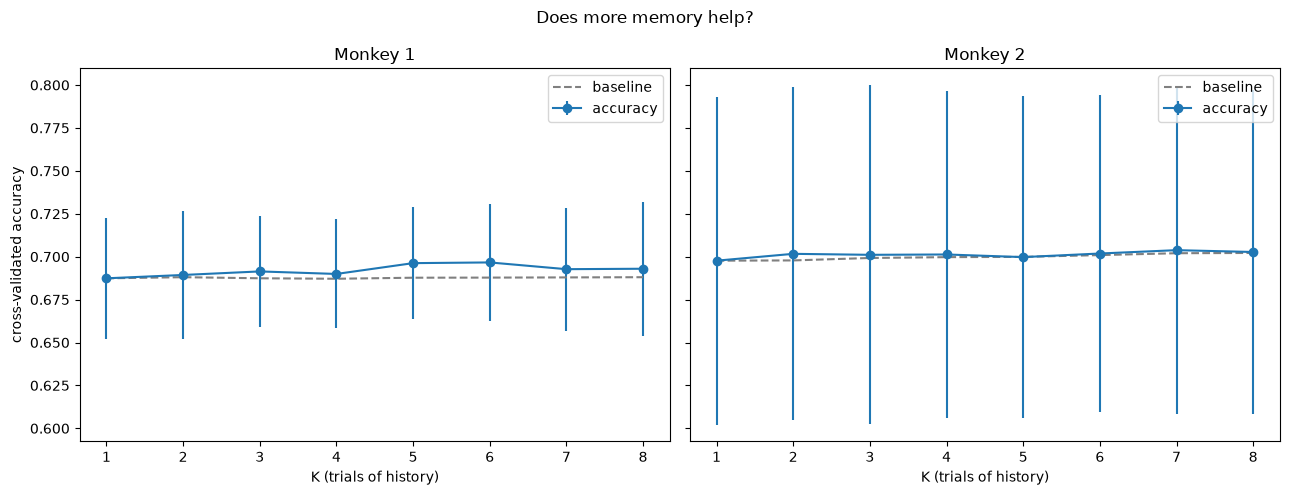

In [10]:
import matplotlib.pyplot as plt

Ks = range(1, 9)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, target in zip(axes, ['decision1', 'decision2']):
    acc_means, acc_stds, base_means = [], [], []
    for K in Ks:
        r = evaluate(lambda: LogisticRegression(max_iter=1000), K=K, sessions=sessions, target=target)
        acc_means.append(r['acc_mean'])
        acc_stds.append(r['acc_std'])
        base_means.append(r['base_mean'])

    monkey = 'Monkey 1' if target == 'decision1' else 'Monkey 2'
    ax.errorbar(list(Ks), acc_means, yerr=acc_stds, marker='o', label='accuracy')
    ax.plot(list(Ks), base_means, '--', color='gray', label='baseline')
    ax.set_title(monkey)
    ax.set_xlabel('K (trials of history)')
    ax.legend()

axes[0].set_ylabel('cross-validated accuracy')
plt.suptitle('Does more memory help?')
plt.tight_layout()
plt.show()

In [11]:
import numpy as np
from sklearn.linear_model import LogisticRegression

for TARGET in ['decision1', 'decision2']:
    monkey = 'Monkey 1' if TARGET == 'decision1' else 'Monkey 2'
    for K in range(1, 5):   # K = 1, 2, 3, 4
        # build features across all sessions
        Xs, ys = [], []
        for s in sessions:
            X, y = build_features(s, K, target=TARGET)
            Xs.append(X); ys.append(y)
        X_all, y_all = np.vstack(Xs), np.concatenate(ys)

        # fit one model on everything
        model = LogisticRegression(max_iter=1000)
        model.fit(X_all, y_all)

        # labels matching feature order: per lag -> [m1, m2]
        labels = []
        for lag in range(1, K + 1):
            labels.append(f"m1 choice {lag}-ago")
            labels.append(f"m2 choice {lag}-ago")

        print(f"=== {monkey} ({TARGET}), K={K} ===")
        print(f"{'intercept':<22} {model.intercept_[0]:+.3f}")
        for label, w in zip(labels, model.coef_[0]):
            print(f"{label:<22} {w:+.3f}")
        print()

=== Monkey 1 (decision1), K=1 ===
intercept              -1.131
m1 choice 1-ago        +0.078
m2 choice 1-ago        +0.925

=== Monkey 1 (decision1), K=2 ===
intercept              -1.236
m1 choice 1-ago        -0.014
m2 choice 1-ago        +0.887
m1 choice 2-ago        +0.022
m2 choice 2-ago        +0.426

=== Monkey 1 (decision1), K=3 ===
intercept              -1.318
m1 choice 1-ago        -0.032
m2 choice 1-ago        +0.859
m1 choice 2-ago        -0.019
m2 choice 2-ago        +0.400
m1 choice 3-ago        +0.189
m2 choice 3-ago        +0.198

=== Monkey 1 (decision1), K=4 ===
intercept              -1.348
m1 choice 1-ago        -0.042
m2 choice 1-ago        +0.858
m1 choice 2-ago        -0.028
m2 choice 2-ago        +0.383
m1 choice 3-ago        +0.178
m2 choice 3-ago        +0.183
m1 choice 4-ago        +0.085
m2 choice 4-ago        +0.080

=== Monkey 2 (decision2), K=1 ===
intercept              -1.086
m1 choice 1-ago        +0.454
m2 choice 1-ago        +0.348

=== Monkey 2 (d